# Banking Fraud & Risk Analytics Platform

## Importing All Required Libraries

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import kaleido

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

%matplotlib inline
from pathlib import Path

Path("../reports/figures").mkdir(parents=True, exist_ok=True)


# Section 1: Data Overview

## Loading the Dataset

In [4]:
transactions = pd.read_csv("../data/processed/cleaned_transaction.csv")

accounts = pd.read_csv("../data/processed/cleaned_accounts.csv")

In [5]:
#Changing the dtype
transactions["timestamp"] = pd.to_datetime(
    transactions["timestamp"]
)

## Creating the copies of dataset

In [6]:
transactions_eda = transactions.copy()

accounts_eda = accounts.copy()

## Dataset Overview

Before beginning the exploratory analysis, the datasets are loaded and inspected to understand their structure, dimensions, data types, and overall characteristics.

## Dataset Shape

In [7]:
print("Transactions Shape :", transactions_eda.shape)

print("Accounts Shape :", accounts_eda.shape)

Transactions Shape : (5078336, 11)
Accounts Shape : (518581, 5)


In [8]:
#Dataset information
transactions_eda.info()
print("--"*50)
accounts_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 5078336 entries, 0 to 5078335
Data columns (total 11 columns):
 #   Column              Dtype         
---  ------              -----         
 0   timestamp           datetime64[us]
 1   from_bank           int64         
 2   sender_account      str           
 3   to_bank             int64         
 4   receiver_account    str           
 5   amount_received     float64       
 6   receiving_currency  str           
 7   amount_paid         float64       
 8   payment_currency    str           
 9   payment_format      str           
 10  is_laundering       int64         
dtypes: datetime64[us](1), float64(2), int64(3), str(5)
memory usage: 622.1 MB
----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 518581 entries, 0 to 518580
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   bank_n

In [9]:
#Statistical Summary
transactions_eda.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,5078336,2022-09-05 07:16:07.855403,2022-09-01 00:00:00,2022-09-02 04:32:00,2022-09-05 12:16:00,2022-09-08 03:13:00,2022-09-18 16:18:00,NaN
from_bank,5078336.0,45730.583254,1.0,119.0,9679.0,28628.0,356303.0,81765.6744
to_bank,5078336.0,65744.609435,1.0,4259.0,21568.0,122332.0,356294.0,84093.026783
amount_received,5078336.0,5988736.683497,0.000001,183.37,1411.04,12346.3,1046302363293.47998,1037184027.926735
amount_paid,5078336.0,4509281.359229,0.000001,184.48,1414.57,12298.15,1046302363293.47998,869773601.619475
is_laundering,5078336.0,0.001019,0.0,0.0,0.0,0.0,1.0,0.031912


In [10]:
accounts_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
bank_id,518581.0,103425.510831,121479.549761,1.0,11107.0,32014.0,217096.0,356303.0


In [11]:
#Missing Values
transactions_eda.isnull().sum()

timestamp             0
from_bank             0
sender_account        0
to_bank               0
receiver_account      0
amount_received       0
receiving_currency    0
amount_paid           0
payment_currency      0
payment_format        0
is_laundering         0
dtype: int64

In [12]:
#Missing Values
accounts_eda.isnull().sum()

bank_name         0
bank_id           0
account_number    0
entity_id         0
entity_name       0
dtype: int64

In [13]:
#Duplicate Values
transactions_eda.duplicated().sum()

np.int64(0)

In [14]:
#Duplicate Values
accounts_eda.duplicated().sum()

np.int64(0)

## Initial Observations

- The Transactions dataset contains over **5 million** financial transactions.
- The Accounts dataset contains over **500 thousand** customer accounts.
- No missing values were detected.
- Duplicate transaction records were removed during the data cleaning phase.
- The datasets are ready for exploratory analysis.

# Section 2: Univariate Analysis

## Objective

The objective of univariate analysis is to examine each variable independently to understand its distribution, frequency, variability, and overall characteristics. This analysis provides a foundational understanding of the banking transactions and account datasets before exploring relationships between multiple variables.

The analysis focuses on:

- Understanding the distribution of categorical variables such as payment methods, currencies, banks, and entity types.
- Examining numerical variables to identify central tendencies, variability, and potential outliers.
- Detecting unusual patterns that may indicate data quality issues or suspicious financial activities.
- Identifying dominant categories and transaction characteristics that influence overall banking operations.
- Establishing a baseline understanding of the data to support subsequent bivariate, multivariate, and fraud-specific analyses.

#### Plot of distribution of payment method 

In [ ]:

payment_counts = (
    transactions_eda["payment_format"]
    .value_counts()
    .reset_index()
)

payment_counts.columns = [
    "Payment Method",
    "Transactions"
]

fig = px.bar(
    payment_counts,
    x="Transactions",
    y="Payment Method",
    orientation="h",
    text="Transactions",
    title="Distribution of Payment Methods",
    color_discrete_sequence=["#1F4E79"]
)




fig.update_layout(

    template="plotly_white",height=550,bargap=0.30,
    title_x=0.5,xaxis_title="Number of Transactions",yaxis_title="Payment Method",showlegend=False
    )
fig.update_xaxes(
    showgrid=False
)
fig.write_image(
    "../reports/figures/payment_method_distribution.png",
    scale=2
)


### Observation

- **Cheque** is the most frequently used payment method, accounting for **1,864,331 transactions (36.71%)** of the total transaction volume.
- **Credit Card** is the second most common payment method with **1,323,324 transactions (26.06%)**.
- Together, **Cheque and Credit Card account for nearly 63% of all transactions**, indicating that the majority of financial activity is concentrated within these two payment channels.
- **ACH (600,793 transactions)**, **Cash (490,891 transactions)**, and **Reinvestment (481,056 transactions)** represent a moderate share of transaction activity.
- **Wire (171,855 transactions)** and **Bitcoin (146,086 transactions)** are the least frequently used payment methods, contributing only a small proportion of the overall transaction volume.

#### Plot of distribution of payment currency

In [22]:
currency = (
    transactions_eda["payment_currency"]
    .value_counts()
    .reset_index()
)

currency.columns = ["Currency","Transactions"]

fig = px.bar(
    currency,
    x="Transactions",
    y="Currency",
    orientation="h",
    text_auto=True,
    title="Payment Currency Distribution",
    color_discrete_sequence=["#791F51"]
)

fig.update_layout(template="plotly_white",margin=dict(l=180, r=40, t=70, b=50))

fig.write_image(
    "../reports/figures/payment_currency_distribution.png",
    scale=2
)

### Observation

- **US Dollar** is the most frequently used payment currency, accounting for **1,895,169 transactions (37.32%)**.
- **Euro** is the second most commonly used currency with **1,168,296 transactions (23.01%)**.
- Together, **US Dollar and Euro account for approximately 60% of all payment transactions**, indicating that the majority of financial activity is concentrated in these two currencies.
- Mid-frequency currencies such as **Swiss Franc, Yuan, Shekel, Rupee, and UK Pound** contribute a moderate share of transaction volume.
- **Brazil Real, Saudi Riyal, Mexican Peso, Australian Dollar, and Canadian Dollar** represent the smallest transaction volumes within the dataset.

#### Distribution plot for Laundering or Legitimate

C:\Users\himan\AppData\Local\Temp\ipykernel_23920\2684498895.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


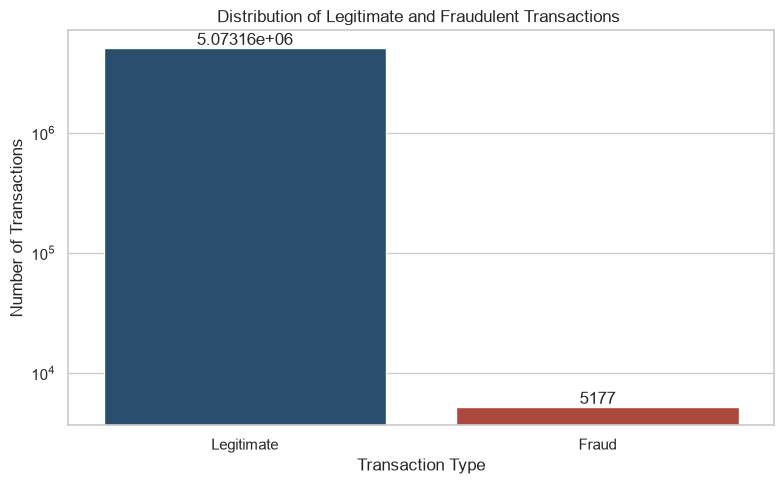

In [23]:
transactions_eda["Transaction Type"] = transactions_eda["is_laundering"].map({
    0: "Legitimate",
    1: "Fraud"
})


plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=transactions_eda,
    x="Transaction Type",
    palette=["#1F4E79", "#C0392B"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.yscale("log")

plt.title("Distribution of Legitimate and Fraudulent Transactions ")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.savefig(
    "../reports/figures/payment_legitimate_and_fraud_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close() 

### Observation

- The dataset contains **5,073,159 legitimate transactions** and **5,177 fraudulent transactions**.
- Fraudulent transactions account for only **0.10%** of the total **5,078,336** transactions, while legitimate transactions represent **99.90%**.
- A logarithmic scale has been applied to the y-axis to effectively visualize the substantial difference in transaction counts between the two classes.
- The visualization highlights the severe class imbalance, with legitimate transactions exceeding fraudulent transactions by approximately **980:1**.

#### Receiving Currency Plot

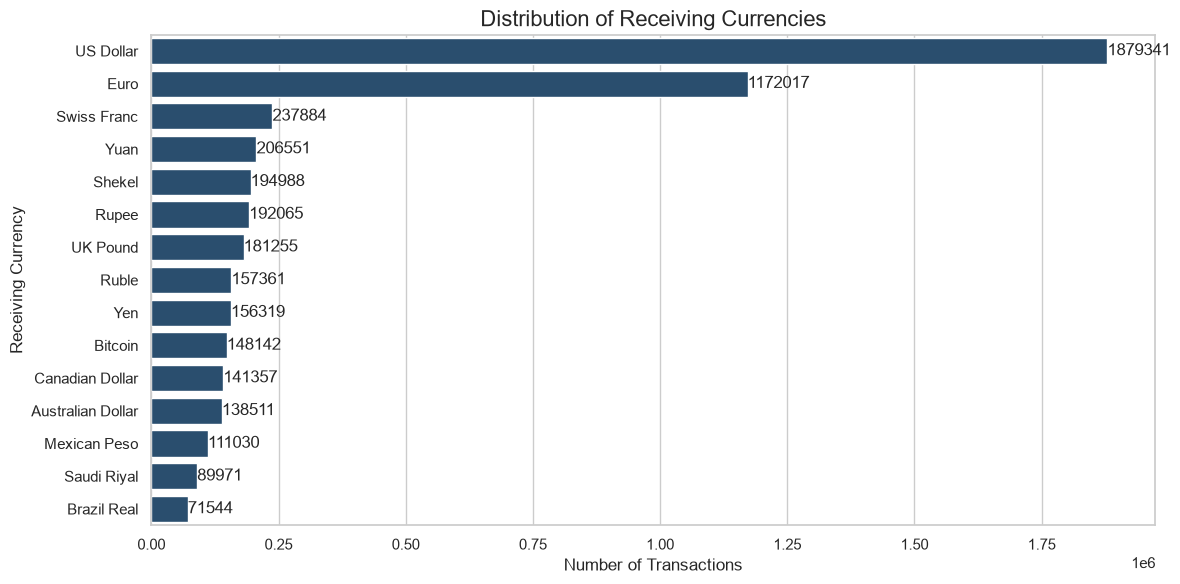

In [24]:
plt.figure(figsize=(12,6))

currency = (
    transactions_eda["receiving_currency"]
    .value_counts()
)

ax = sns.barplot(
    x=currency.values,
    y=currency.index,
    color="#1F4E79"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Distribution of Receiving Currencies", fontsize=16)
plt.xlabel("Number of Transactions")
plt.ylabel("Receiving Currency")

plt.tight_layout()
plt.savefig(
    "../reports/figures/receivin_currencies_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
 

### Observation

- The dataset supports transactions across **15 different receiving currencies**, indicating a globally diversified banking network.
- **US Dollar** is the most frequently received currency with approximately **1.88 million** transactions, accounting for nearly **37%** of all incoming transactions.
- **Euro** is the second most common receiving currency with around **1.17 million** transactions.
- After the top two currencies, transaction frequencies decline significantly, with all remaining currencies individually contributing less than **250,000** transactions.
- Less frequently used currencies such as **Brazil Real** and **Saudi Riyal** represent niche transaction volumes within the dataset.

#### Top Bank by Number of Accounts 

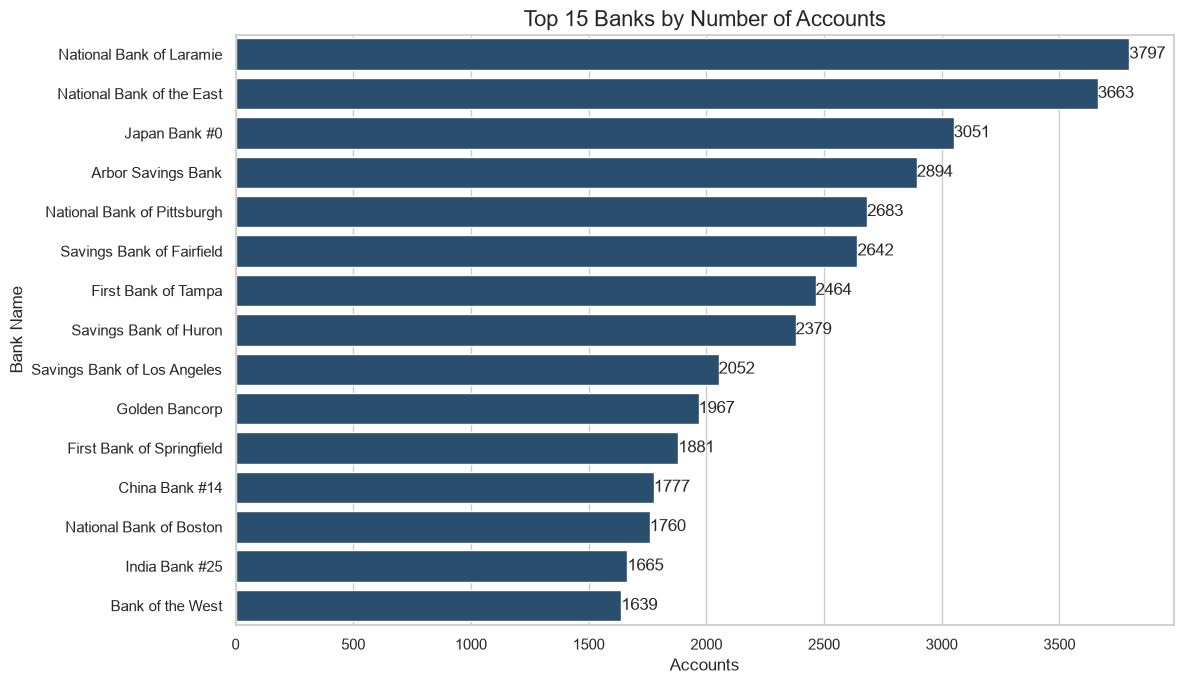

In [25]:
top_bank = (
    accounts_eda["bank_name"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=top_bank.values,
    y=top_bank.index,
    color="#1F4E79"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 15 Banks by Number of Accounts", fontsize=16)
plt.xlabel("Accounts")
plt.ylabel("Bank Name")

plt.tight_layout()
plt.savefig(
    "../reports/figures/top_15_bank_by_number_of_accounts.png",
    dpi=300,
    bbox_inches="tight"
)


### Observation

- The dataset contains more than **20,000 unique banks**, demonstrating a highly distributed banking ecosystem.
- **National Bank of Laramie** maintains the largest customer base with **3,797 accounts**, followed by **National Bank of the East** with **3,663 accounts**.
- The top fifteen banks have account counts ranging from approximately **1,600 to 3,800**, indicating that customer accounts are relatively well distributed rather than being concentrated within a few institutions.
- No single bank overwhelmingly dominates the account distribution, suggesting a balanced representation across participating financial institutions.

#### Plot of Distribution of Entity Type

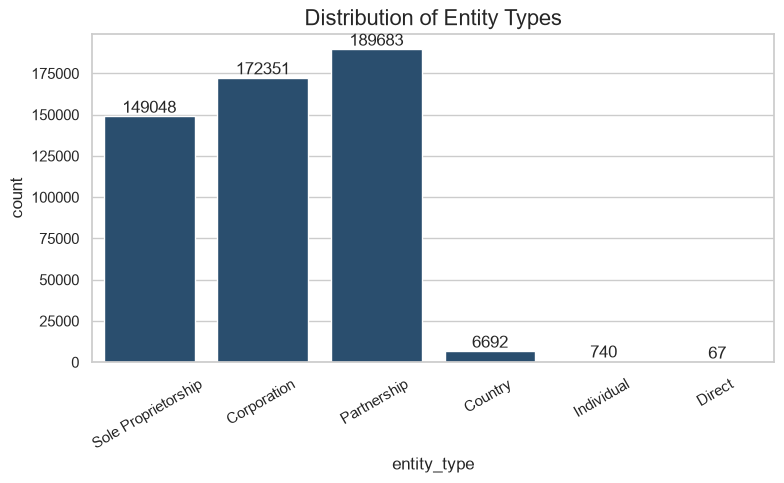

In [26]:
accounts_eda["entity_type"] = (
    accounts_eda["entity_name"]
    .str.split("#")
    .str[0]
)

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=accounts_eda,
    x="entity_type",
    color="#1F4E79"
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=30)

plt.title("Distribution of Entity Types", fontsize=16)

plt.tight_layout()

plt.savefig(
    "../reports/figures/Entity_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close() 

### Observation

- The dataset primarily consists of **Partnerships (189,683)**, **Corporations (172,351)**, and **Sole Proprietorships (149,048)**.
- These three business entity categories account for the overwhelming majority of customer accounts.
- Individual accounts are extremely limited (**740 accounts**), while **Direct** entities are nearly absent (**67 accounts**).
- County organizations also represent a relatively small portion of the dataset.

#### BoxPlot for Transaction Amount

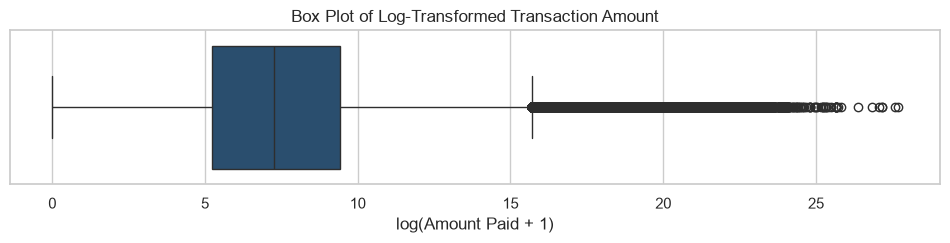

In [27]:
plt.figure(figsize=(12,2))

sns.boxplot(
    x=np.log1p(transactions_eda["amount_paid"]),
    color="#1F4E79"
)

plt.title("Box Plot of Log-Transformed Transaction Amount")

plt.xlabel("log(Amount Paid + 1)")

plt.savefig(
    "../reports/figures/boxplot_transaction_account.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close() 

### Observation

- Log transformation significantly improves the visualization of transaction amounts by reducing the impact of extremely large values.
- Most transaction amounts fall within a relatively compact range after transformation.
- A considerable number of high-value outliers remain visible even after applying the logarithmic transformation.
- The presence of these extreme observations indicates that the dataset contains several unusually large financial transactions.

#### Violion Plot for amount distribution

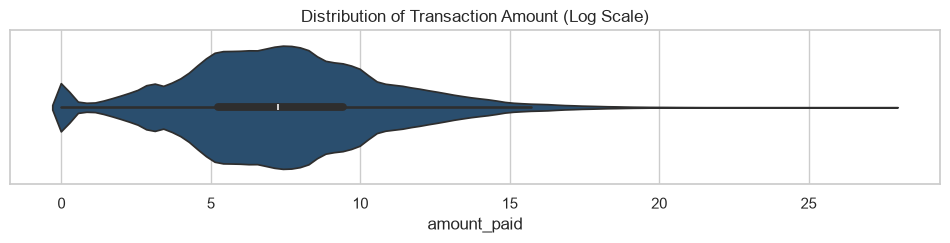

In [28]:
plt.figure(figsize=(12,2))

sns.violinplot(
    x=np.log1p(transactions_eda["amount_paid"]),
    color="#1F4E79"
)

plt.title("Distribution of Transaction Amount (Log Scale)")

plt.savefig(
    "../reports/figures/violion_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close() 

### Observation

- The highest density of transactions is concentrated around the middle transaction values after log transformation.
- The distribution exhibits a long right tail, confirming that a relatively small number of transactions involve exceptionally large amounts.
- The median lies near the center of the dense region, while transaction frequencies gradually decrease as transaction amounts increase.
- Overall, transaction amounts remain positively skewed even after logarithmic transformation.

#### Plot of share of payment format

In [29]:
payment = (
    transactions_eda["payment_format"]
    .value_counts()
    .reset_index()
)

payment.columns = ["Payment Method", "Transactions"]

fig = px.pie(
    payment,
    values="Transactions",
    names="Payment Method",
    hole=0.55,
    title="Share of Payment Methods"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.write_image(
    "../reports/figures/barplot_share_of_payment_method.png",
    scale=2
)

### Observation

- **Cheque** is the most frequently used payment method, accounting for approximately **36.7%** of all transactions.
- **Credit Card** transactions represent approximately **26.1%**, making it the second most common payment channel.
- **ACH**, **Cash**, and **Reinvestment** each contribute between **9% and 12%** of total transactions.
- **Wire transfers** and **Bitcoin** represent the smallest transaction shares, together accounting for less than **7%** of all transactions.
- Payment activity is concentrated among traditional financial instruments rather than digital assets.

# Section 3: Bivariate Analysis

## Objective

The objective of bivariate analysis is to examine the relationship between two variables in order to identify patterns, dependencies, and potential fraud indicators. Unlike univariate analysis, which focuses on a single feature, bivariate analysis helps uncover how transaction characteristics influence one another and whether specific attributes are associated with suspicious financial activities.

The analysis aims to:

- Identify relationships between payment methods and fraudulent transactions.
- Compare transaction amounts across different payment channels and currencies.
- Examine how transaction patterns vary across banks and entity types.
- Discover business insights that support fraud detection and risk assessment.

#### Bar plot fraud accross different payment method

In [30]:
fraud_payment = (
    transactions_eda
    .groupby("payment_format")["is_laundering"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

fraud_payment.columns = ["Payment Method", "Fraud Rate (%)"]

fig = px.bar(
    fraud_payment,
    x="Payment Method",
    y="Fraud Rate (%)",
    text="Fraud Rate (%)",
    color="Fraud Rate (%)",
    color_continuous_scale="YlOrRd",
    title="Fraud Rate Across Different Payment Methods"
)

fig.update_traces(
    texttemplate="%{y:.3f}%",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Payment Method",
    yaxis_title="Fraud Rate (%)",
    coloraxis_showscale=False
)

fig.write_image(
    "../reports/figures/Fraud_Rate_Across_Different_Payment_Methods.png",
    scale=2
)

### Observation

- ACH transactions exhibit the highest fraud rate at approximately **0.746%**, making it the most fraud-prone payment method in the dataset.
- Bitcoin ranks second with a fraud rate of approximately **0.038%**, although it remains significantly lower than ACH.
- Cash (**0.022%**), Cheque (**0.017%**), and Credit Card (**0.016%**) demonstrate relatively low fraud rates.
- Reinvestment and Wire transactions show an almost negligible fraud rate, indicating very few or no recorded fraudulent transactions in the available dataset.
- The substantial difference between ACH and all other payment methods suggests that fraudulent activity is disproportionately concentrated within ACH transactions rather than being uniformly distributed across payment channels.

#### Plot of fraud rate accross different currency

In [31]:
fraud_currency = (
    transactions_eda
    .groupby("payment_currency")["is_laundering"]
    .mean()
    .mul(100)
    .sort_values(ascending=True)
    .reset_index()
)

fraud_currency.columns = ["Payment Currency", "Fraud Rate (%)"]

fig = px.bar(
    fraud_currency,
    x="Fraud Rate (%)",
    y="Payment Currency",
    orientation="h",
    color="Fraud Rate (%)",
    color_continuous_scale="YlOrRd",
    text="Fraud Rate (%)",
    title="Fraud Rate Across Different Payment Currencies"
)

fig.update_traces(
    texttemplate="%{x:.3f}%",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    title={
        "text": "<b>Fraud Rate Across Different Payment Currencies</b>",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Fraud Rate (%)",
    yaxis_title="Payment Currency",
    coloraxis_showscale=False,
    height=650,
    font=dict(size=14)
)
fig.write_image(
    "../reports/figures/Fraud Rate Across Different Payment Currencies.png",
    scale=2
)

### Observation

- **Saudi Riyal** exhibits the highest fraud rate (**0.420%**), significantly exceeding all other payment currencies and indicating a comparatively higher proportion of fraudulent transactions.
- **Euro (0.117%)**, **US Dollar (0.101%)**, and **Yen (0.100%)** form the second-highest risk group, although their fraud rates remain considerably lower than Saudi Riyal.
- The majority of payment currencies have fraud rates ranging between **0.07% and 0.10%**, suggesting relatively consistent fraud levels across most currencies.
- **Bitcoin** records the lowest fraud rate (**0.038%**) in this dataset, indicating that it contributes a relatively small proportion of fraudulent transactions despite its association with financial crime in real-world scenarios.
- The noticeable variation in fraud rates across different currencies suggests that **payment currency is a potentially informative feature** for fraud detection and risk assessment models.
- Overall, fraud rates remain below **0.5%** for every currency, reinforcing the highly imbalanced nature of the dataset where fraudulent transactions constitute only a very small fraction of total transactions.

In [32]:
# Create log-transformed transaction amount
transactions_eda["log_amount_paid"] = np.log1p(transactions_eda["amount_paid"])

fig = px.box(
    transactions_eda,
    x="payment_format",
    y="log_amount_paid",
    color="payment_format",
    color_discrete_sequence=px.colors.qualitative.Set2,
    points=False,
    title="Distribution of Transaction Amounts Across Payment Methods"
)

fig.update_layout(
    template="plotly_white",
    title={
        "text": "<b>Distribution of Transaction Amounts Across Payment Methods</b>",
        "x": 0.5
    },
    xaxis_title="Payment Method",
    yaxis_title="Log(Transaction Amount + 1)",
    height=550,
    width=900,
    showlegend=False,
    margin=dict(l=70, r=30, t=70, b=60)
)

fig.update_xaxes(showline=True, linecolor="black")
fig.update_yaxes(showline=True, linecolor="black", gridcolor="lightgray")

fig.write_image(
    "../reports/figures/Distribution of Transaction Amounts Across Payment Methods.png",
    scale=2
)

### Observation

- Transaction amounts vary considerably across different payment methods, indicating that each payment channel is used for transactions of different monetary values.
- **ACH, Cash, Wire, Reinvestment, and Cheque** exhibit relatively wide interquartile ranges (IQR), suggesting substantial variability in transaction amounts.
- **Credit Card** transactions display a comparatively narrower distribution, indicating more consistent transaction values.
- **Bitcoin** transactions are heavily concentrated near the lower end of the scale, with a very small median transaction amount and limited variability compared to other payment methods.
- Several payment methods have long upper whiskers, implying the presence of very high-value transactions even after logarithmic transformation.
- The use of logarithmic transformation successfully reduces the impact of extreme transaction amounts, allowing meaningful comparison of transaction distributions across all payment methods.

In [33]:
top_currency = (
    transactions_eda["payment_currency"]
    .value_counts()
    .head(10)
    .index
)

currency_plot = transactions_eda[
    transactions_eda["payment_currency"].isin(top_currency)
]

fig = px.violin(
    currency_plot,
    x="payment_currency",
    y="log_amount_paid",
    color="payment_currency",
    box=True,
    points=False,
    color_discrete_sequence=px.colors.qualitative.Set3,
    title="Distribution of Transaction Amounts Across Top 10 Payment Currencies"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Payment Currency",
    yaxis_title="Log(Transaction Amount + 1)",
    height=600,
    width=950,
    showlegend=False
)

fig.update_xaxes(tickangle=40)

fig.write_image(
    "../reports/figures/Distribution of Transaction Amounts Across Top 10 Payment Currencies.png",
    scale=2
)

### Observations

- Transaction amounts vary considerably across different payment currencies, indicating that the typical value of transactions depends on the currency being used.

- **Japanese Yen, Indian Rupee, and Russian Ruble** show relatively higher median transaction amounts, suggesting that transactions in these currencies generally involve larger values.

- **Bitcoin** exhibits the lowest transaction values, with most observations concentrated near zero on the log scale, indicating comparatively smaller transaction amounts.

- Most currencies display a wide distribution of transaction amounts, as reflected by the long whiskers, suggesting the presence of both low-value and high-value transactions.

- Several currencies contain **extreme high-value transactions (outliers)**, with transaction amounts extending well above the upper quartile. These transactions may require additional investigation during fraud analysis.

- The **interquartile range (IQR)** differs across currencies, indicating varying levels of transaction value variability. Currencies such as Yen and Rupee exhibit greater dispersion than Bitcoin.

- The application of a **log transformation** successfully reduces the effect of highly skewed transaction values, making comparisons across different currencies more meaningful and interpretable.

- Overall, transaction amount distributions are not identical across currencies, highlighting that **payment currency is an important feature** and may provide valuable information for fraud detection and risk assessment.

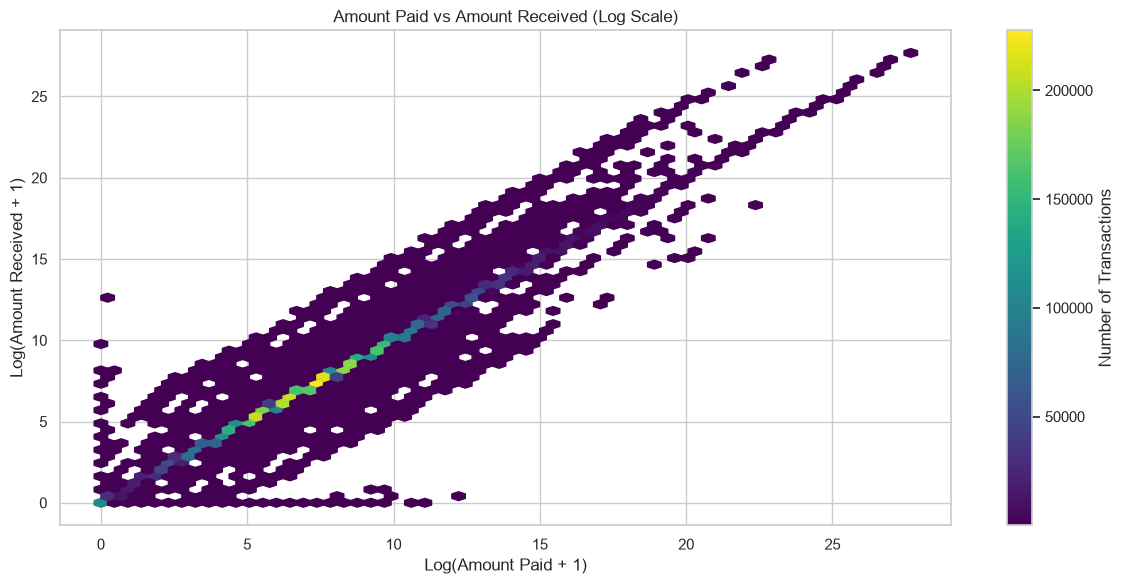

In [37]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.hexbin(
    np.log1p(transactions["amount_paid"]),
    np.log1p(transactions["amount_received"]),
    gridsize=60,
    cmap="viridis",
    mincnt=1
)

plt.colorbar(label="Number of Transactions")

plt.title("Amount Paid vs Amount Received (Log Scale)")
plt.xlabel("Log(Amount Paid + 1)")
plt.ylabel("Log(Amount Received + 1)")

plt.tight_layout()
plt.savefig(
    "../reports/figures/Amount Paid vs Amount Received (Log Scale).png",
    dpi=300,
    bbox_inches="tight"
)

### Observations

- A **strong positive linear relationship** exists between **Amount Paid** and **Amount Received**. As the amount paid increases, the amount received also increases, indicating a high degree of correlation between the two variables.

- The majority of transactions are concentrated along the **main diagonal**, suggesting that for most transactions, the paid and received amounts are nearly equal after accounting for currency conversion or transaction fees.

- The **highest transaction density** is observed in the lower-to-middle range of transaction amounts (approximately **Log 5–9**), indicating that most transactions involve relatively moderate values.

- As transaction amounts increase, the **density of transactions decreases**, implying that high-value transactions are considerably less frequent than low-value transactions.

- Several transactions deviate from the primary diagonal, indicating differences between the paid and received amounts. These deviations may result from **currency exchange rates, transfer fees, exchange spreads, or potentially suspicious transaction patterns**.

- A small number of transactions appear near the x-axis or y-axis, representing cases where either the paid or received amount is extremely small compared to the other. These observations should be investigated further during anomaly detection.

- The **logarithmic transformation** effectively compresses the wide range of transaction values, making both low-value and high-value transactions visible within the same visualization and reducing the impact of extreme values.

- Overall, the scatter plot indicates that **Amount Paid** and **Amount Received** are highly correlated variables, making them valuable features for transaction analysis and fraud detection.

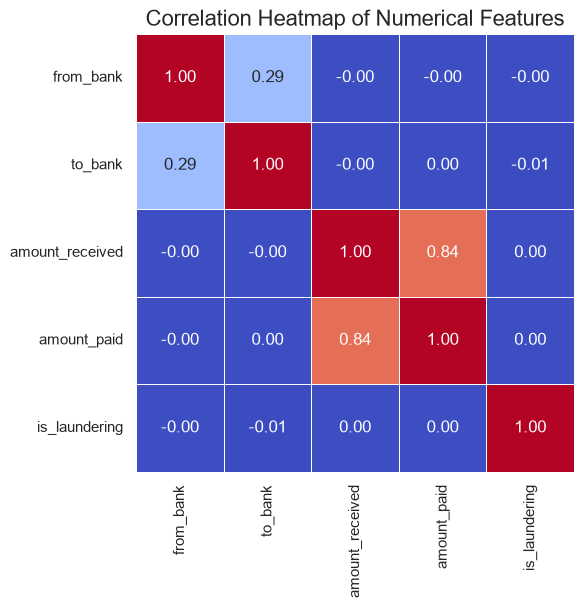

In [42]:
numeric_df = transactions.select_dtypes(include=["number"])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot
plt.figure(figsize=(6, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    cbar=False
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()

plt.savefig(
    "../reports/figures/Correlation Heatmap of Numerical Features.png",
    dpi=300,
    bbox_inches="tight"
)

### Observations

- The strongest positive correlation is observed between **Amount Paid** and **Amount Received** (**r = 0.84**), indicating that transactions with higher payment amounts generally correspond to higher received amounts.

- **From Bank** and **To Bank** exhibit a **weak positive correlation** (**r = 0.29**), suggesting a slight relationship between the originating and receiving banks, but not a strong dependency.

- The target variable, **Is Laundering**, shows **almost no linear correlation** with the available numerical features. Correlation coefficients are close to **0**, indicating that fraudulent transactions cannot be identified using these numerical variables alone.

- Both **Amount Paid** and **Amount Received** have virtually **no linear correlation** with the fraud label, suggesting that transaction amount by itself is not a strong indicator of money laundering.

- Similarly, **From Bank** and **To Bank** have negligible correlation with the fraud label, implying that bank identifiers alone provide limited predictive information in their numerical form.

- No evidence of severe multicollinearity exists among the numerical features, except for the expected strong relationship between **Amount Paid** and **Amount Received**.

- The weak correlations between the fraud label and numerical features indicate that **categorical variables** (such as payment currency, payment format, entity type, and bank combinations) and **engineered features** are likely to be more informative for fraud detection.


# Section 4: Multivariate Analysis

## Objective

The objective of multivariate analysis is to examine the relationships among **three or more variables simultaneously** in order to uncover complex transaction patterns that cannot be identified through univariate or bivariate analysis alone.

In the context of fraud detection, multivariate analysis helps answer questions such as:

- Which combinations of **payment methods** and **currencies** exhibit the highest fraud rates?
- How does **entity type** influence fraudulent transactions across different payment methods?
- Which **currency pairs** are most frequently involved in transactions?
- How do **transaction amounts** vary across different entity types and fraud classes?

These insights help identify high-risk combinations of transaction attributes, improve understanding of laundering behavior, and provide valuable information for feature engineering and predictive fraud detection models.

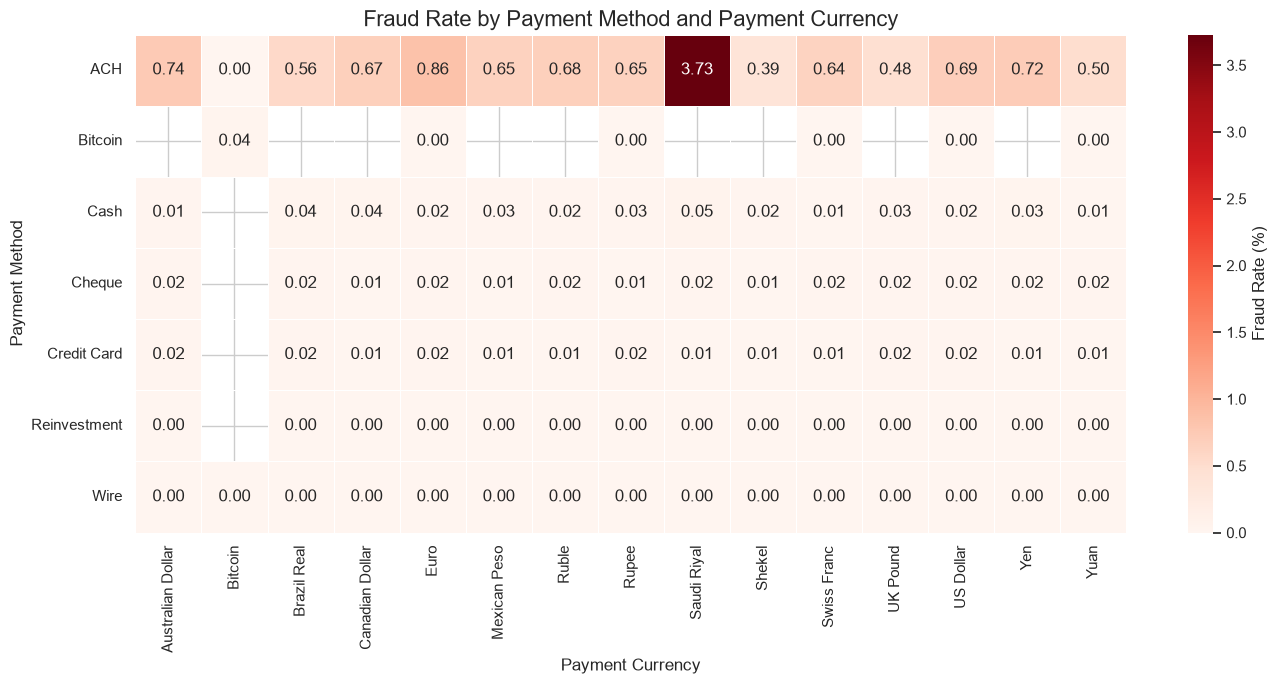

In [46]:
fraud_rate = (
    transactions
    .groupby(["payment_format", "payment_currency"])["is_laundering"]
    .mean()
    .mul(100)
    .reset_index(name="Fraud Rate (%)")
)

# Create pivot table
heatmap_data = fraud_rate.pivot(
    index="payment_format",
    columns="payment_currency",
    values="Fraud Rate (%)"
)

# Plot
plt.figure(figsize=(14,7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label": "Fraud Rate (%)"}
)

plt.title("Fraud Rate by Payment Method and Payment Currency", fontsize=16)
plt.xlabel("Payment Currency")
plt.ylabel("Payment Method")

plt.tight_layout()

# Save figure
plt.savefig(
    "../reports/figures/fraud_rate_payment_method_currency_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)


### Observations

- Fraud rates vary considerably across different **payment method and payment currency** combinations, indicating that fraud risk depends on the interaction of multiple transaction attributes rather than a single feature.

- **ACH** transactions consistently exhibit the **highest fraud rates** across almost all payment currencies, making ACH the most vulnerable payment method in the dataset.

- The combination of **ACH** and **Saudi Riyal** records the **highest observed fraud rate (3.73%)**, making it the riskiest payment method–currency combination in this analysis.

- ACH transactions involving **Euro, Australian Dollar, Canadian Dollar, Yen, US Dollar, and Ruble** also display relatively elevated fraud rates compared to other payment methods.

- **Cash, Cheque, and Credit Card** transactions exhibit consistently **low fraud rates**, generally below **0.05%**, suggesting that these payment methods are associated with fewer laundering cases in the dataset.

- **Wire** and **Reinvestment** transactions show virtually **zero fraud rate** across all payment currencies, indicating that no significant laundering activity was recorded for these payment methods in the available data.

- **Bitcoin** transactions display negligible fraud rates despite appearing across multiple currencies, suggesting that money laundering within this synthetic dataset is not concentrated in Bitcoin payment methods.

- Overall, the heatmap demonstrates that **payment method has a stronger influence on fraud occurrence than payment currency**, with ACH emerging as the primary high-risk payment channel.


In [53]:
transactions_eda.columns

Index(['timestamp', 'from_bank', 'sender_account', 'to_bank',
       'receiver_account', 'amount_received', 'receiving_currency',
       'amount_paid', 'payment_currency', 'payment_format', 'is_laundering',
       'Transaction Type', 'log_amount_paid'],
      dtype='str')

In [ ]:
fraud_df = transactions[transactions["is_laundering"] == 1]

# Count fraud transactions by payment method
fraud_counts = fraud_df["payment_format"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    fraud_counts,
    labels=fraud_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"white"}
)

plt.title("Fraud Transaction Distribution by Payment Method")

plt.tight_layout()

# Save figure
plt.savefig(
    "../reports/figures/fraud_payment_method_pie_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()